## Import

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from datetime import *
from functools import partial
import multiprocessing

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn.colors.xkcd_rgb as c
import cmaps

In [2]:
import vvmtoolsV2
import importlib
importlib.reload(vvmtoolsV2)

<module 'vvmtoolsV2' from '/data/ch995334/2024ClDyn/CODE/vvmtoolsV2.py'>

In [50]:
import matplotlib.cm as cm

## Output format-controlled .nc files
- case path `/data/C.shaoyu/ml_pbl`
- 5 land type, 10 combinations: `urban`, `barren soil`, `pasture`, `grass`, `evergreen needle`
- 3 soundings: `1p0km`(the most stable), `1p5km`, `2p0km`(the most unstable)

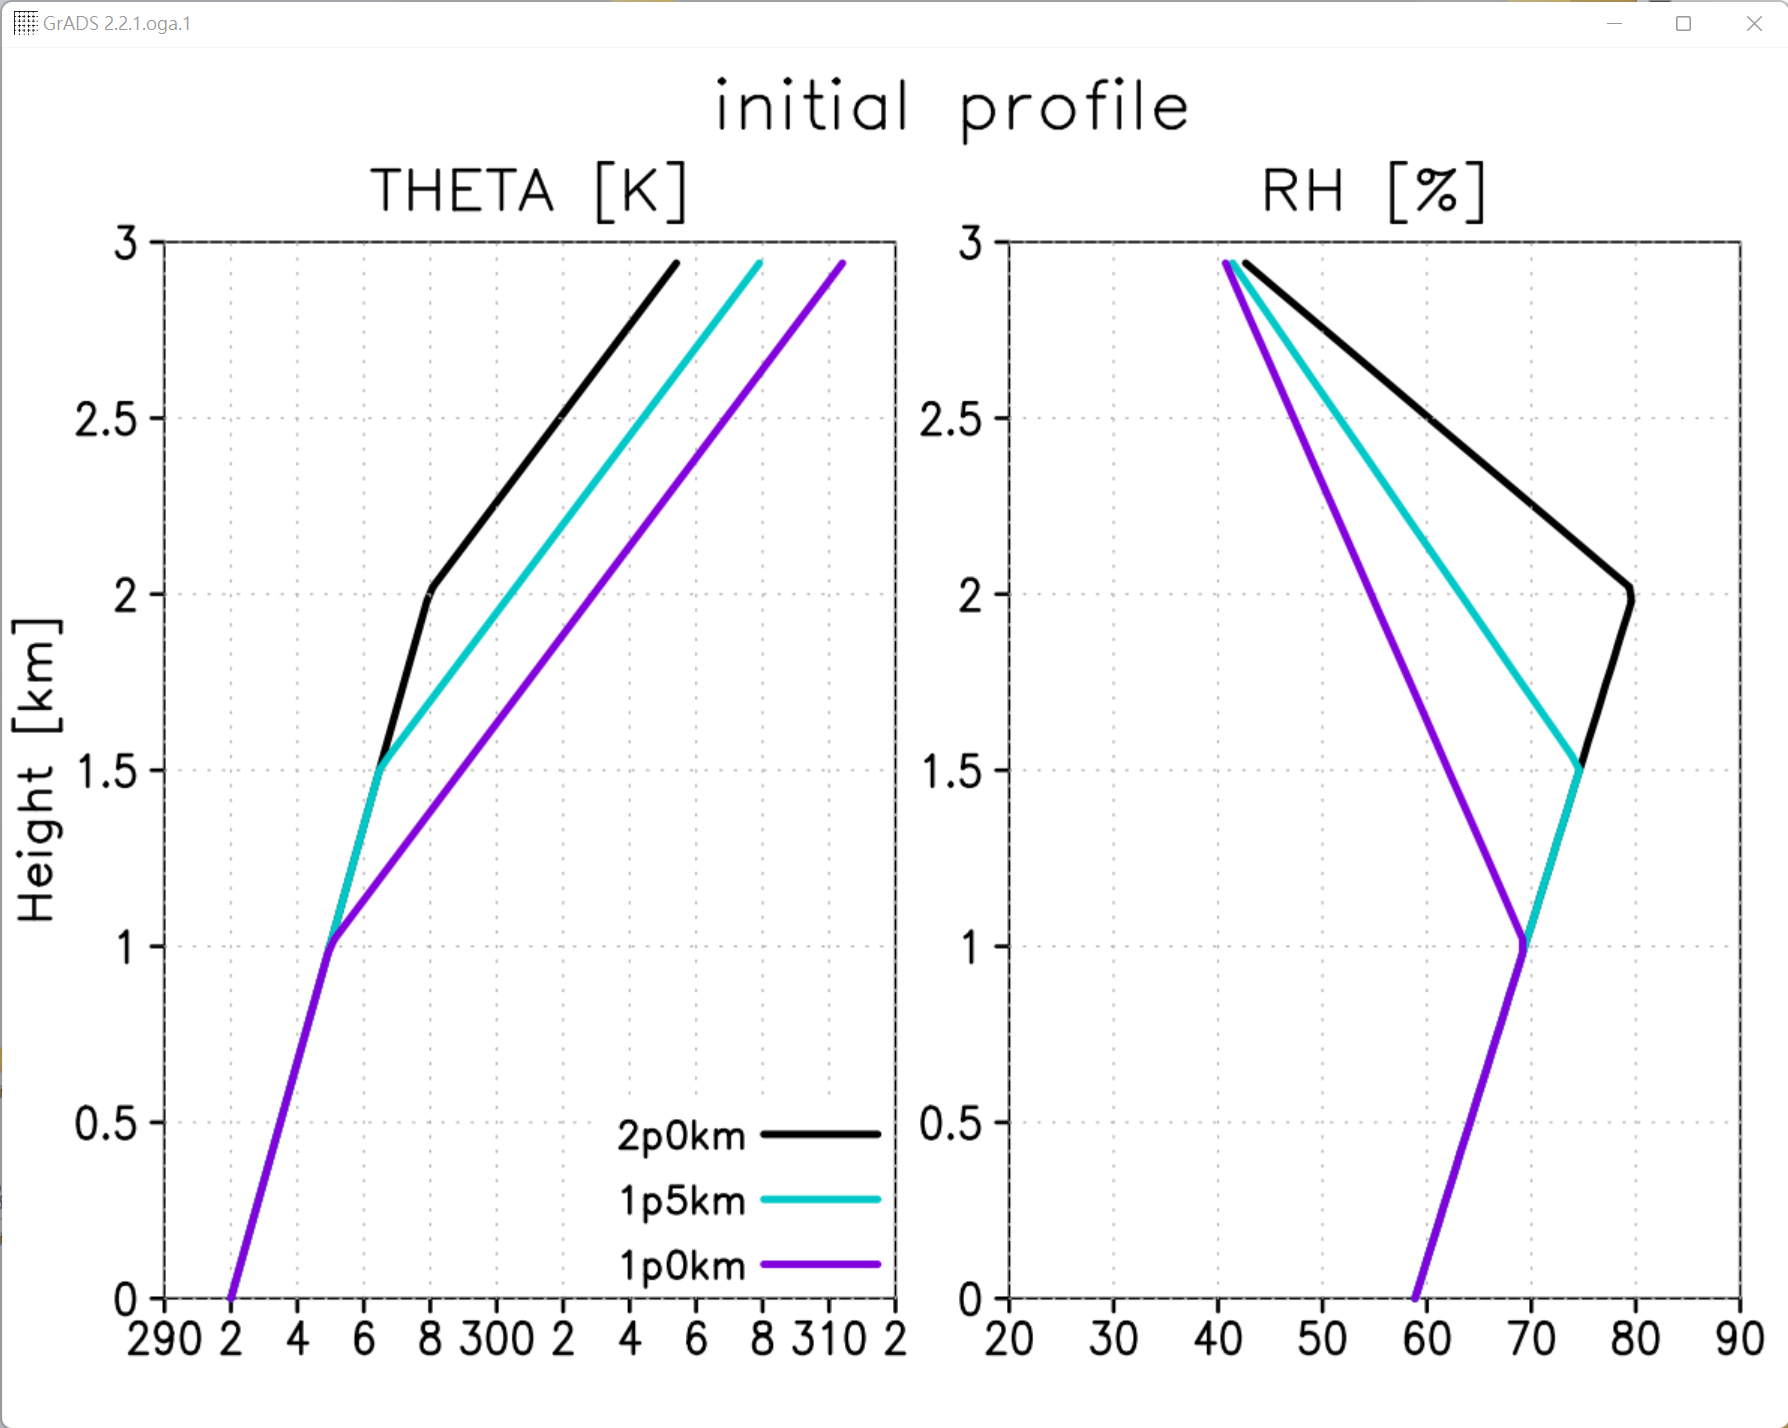

In [5]:
!ls -l /data/C.shaoyu/ml_pbl

total 75
drwxr-xr-x. 8 C.shaoyu users 33 Jan  2 10:04 pbl_bu_1p0km
drwxr-xr-x. 8 C.shaoyu users 33 Jan  2 10:04 pbl_bu_1p5km
drwxr-xr-x. 8 C.shaoyu users 33 Jan  2 10:04 pbl_bu_2p0km
drwxr-xr-x. 8 C.shaoyu users 33 Jan  2 10:05 pbl_eb_1p0km
drwxr-xr-x. 8 C.shaoyu users 33 Jan  2 10:05 pbl_eb_1p5km
drwxr-xr-x. 8 C.shaoyu users 33 Jan  2 10:05 pbl_eb_2p0km
drwxr-xr-x. 8 C.shaoyu users 33 Jan  2 10:05 pbl_eu_1p0km
drwxr-xr-x. 8 C.shaoyu users 33 Jan  2 10:05 pbl_eu_1p5km
drwxr-xr-x. 8 C.shaoyu users 33 Jan  2 10:05 pbl_eu_2p0km
drwxr-xr-x. 8 C.shaoyu users 33 Jan  2 10:05 pbl_gb_1p0km
drwxr-xr-x. 8 C.shaoyu users 33 Jan  2 10:06 pbl_gb_1p5km
drwxr-xr-x. 8 C.shaoyu users 33 Jan  2 10:06 pbl_gb_2p0km
drwxr-xr-x. 8 C.shaoyu users 33 Jan  2 10:06 pbl_ge_1p0km
drwxr-xr-x. 8 C.shaoyu users 33 Jan  2 10:06 pbl_ge_1p5km
drwxr-xr-x. 8 C.shaoyu users 33 Jan  2 10:06 pbl_ge_2p0km
drwxr-xr-x. 8 C.shaoyu users 33 Jan  2 10:06 pbl_gp_1p0km
drwxr-xr-x. 8 C.shaoyu users 33 Jan  2 12:01 pbl_gp_1p5km
drwxr

### Function

In [10]:
import vvmtools  # version 1.1.0
def Output_to_nc(lu:str, sounding:str):
    mytools_case = vvmtoolsV2.VVMtools(f"/data/C.shaoyu/ml_pbl/pbl_{lu}_{sounding}")
    # Get domain-averaged theta, enstrophy, tke, w'th' (a-grid)
    domain_range = (None, None, None, None, None, None)
    th_agrid     = mytools_case.get_var_parallel('th', np.arange(721))
    th_mean      = th_agrid.mean(axis=(-2, -1))
    enst_agrid   = mytools_case.func_time_parallel(func=mytools_case.cal_enstrophy,
                                                   time_steps=np.arange(721),
                                                   func_config={'domain_range':domain_range}, cores=10)
    enst_format  = np.concatenate((np.zeros((enst_agrid.shape[0], 1)), enst_agrid), axis=1)
    tke_agrid    = mytools_case.func_time_parallel(func=mytools_case.cal_TKE,
                                                   time_steps=np.arange(721),
                                                   func_config={'domain_range':domain_range}, cores=10)
    tke_format   = np.concatenate((np.zeros((tke_agrid.shape[0], 1)), tke_agrid), axis=1)
    wth_agrid    = mytools_case.func_time_parallel(func=mytools_case.cal_turb_flux,
                                                   time_steps=np.arange(721),
                                                   func_config={'domain_range':domain_range,
                                                                'wind_var':'w',
                                                                'prop_var':'th'}, cores=10)
    wth_mean     = wth_agrid.mean(axis=(-2, -1))
    wth_format   = np.concatenate((np.zeros((wth_mean.shape[0], 1)), wth_mean), axis=1)
    
    # Create .nc file
    nz, nt = 75, 721
    dim_data_dict = {
        "time": (np.arange(nt)*np.timedelta64(2,'m')+np.datetime64('2024-01-01 05:00:00')).astype('datetime64[s]'),
        "height": np.arange(nz)*0.04
    }
    data_dict = {
        "th": th_mean,
        "enstrophy": enst_format,
        "tke": tke_format,
        "wth": wth_format
    }
    var_dims_dict = {
        "th": ("time", "height"),
        "enstrophy": ("time", "height"),
        "tke": ("time", "height"),
        "wth": ("time", "height")
    }
    attributes = {
        "th": {"units": "K", "description": "x-y mean potential temperature (t,z)"},
        "enstrophy": {"units": "1/(s^2)", "description": "x-y mean enstrophy (t,z)"},
        "tke": {"units": "(m^2)/(s^2)", "description": "x-y mean turbulent kinetic energy (t,z)"},
        "wth": {"units": "(m/s)*(K)", "description": "x-y mean turbulent flux (t,z)"},
        "time": {"description": "Local Time"},  # Removed 'units' for time
        "height": {"units": "m", "description": "Height in grid center"},
    }

    # Example of creating a NetCDF file with flexible dimensions
    vvmtools.analyze.create_nc_output(f"/data/ch995334/2024ClDyn/TemporaryData/lu_profs/{lu}_{sounding}.nc", 
                                      dim_data_dict, data_dict, var_dims_dict, attributes)

### Create .nc files

In [8]:
lu_list       = ['bu', 'eb', 'eu', 'gb', 'ge', 'gp', 'gu', 'pb', 'pe', 'pu']
sounding_list = ['1p0km', '1p5km', '2p0km']

In [11]:
for lu in lu_list:
    for sd in sounding_list:
        Output_to_nc(lu=lu, sounding=sd)

NetCDF file '/data/ch995334/2024ClDyn/TemporaryData/lu_profs/bu_1p0km.nc' created successfully.


NetCDF file '/data/ch995334/2024ClDyn/TemporaryData/lu_profs/bu_1p5km.nc' created successfully.


NetCDF file '/data/ch995334/2024ClDyn/TemporaryData/lu_profs/bu_2p0km.nc' created successfully.


NetCDF file '/data/ch995334/2024ClDyn/TemporaryData/lu_profs/eb_1p0km.nc' created successfully.


NetCDF file '/data/ch995334/2024ClDyn/TemporaryData/lu_profs/eb_1p5km.nc' created successfully.


...

NetCDF file '/data/ch995334/2024ClDyn/TemporaryData/lu_profs/pe_1p5km.nc' created successfully.


NetCDF file '/data/ch995334/2024ClDyn/TemporaryData/lu_profs/pe_2p0km.nc' created successfully.


NetCDF file '/data/ch995334/2024ClDyn/TemporaryData/lu_profs/pu_1p0km.nc' created successfully.


NetCDF file '/data/ch995334/2024ClDyn/TemporaryData/lu_profs/pu_1p5km.nc' created successfully.


NetCDF file '/data/ch995334/2024ClDyn/TemporaryData/lu_profs/pu_2p0km.nc' created successfully.


## Vertical profile evolution

In [130]:
def Plot_all_lu_profiles(var:str, sounding:str, savefig:bool=False):
    # Figure initialization
    fig, ax = plt.subplots(2, 5, sharex=True, sharey=True, figsize=(20, 12), gridspec_kw={'wspace':0.22})
    # cmap    = cmaps.WhiteBlueGreenYellowRed[10:]
    cmap    = cmaps.radar[:-1]
    ccolors = cmap(np.linspace(0, 1, 14))
    # Data initialization
    lu_list = ['eu', 'gu', 'pu', 'bu', 'pb', 'gp', 'pe', 'ge', 'eb', 'gb']
    time_int= 30
    time_stp= 391
    for i, axe in enumerate(ax.flatten()):
        ds_lusd = xr.open_dataset(f'../TemporaryData/lu_profs/{lu_list[i]}_{sounding}.nc')
        for t in range(int(time_stp/time_int)):
            y = ds_lusd.height
            if var == 'th_diff':
                axe.plot(ds_lusd.th.isel(time=int(t*time_int+1))-ds_lusd.th.isel(time=int(t*time_int)), y, color=ccolors[t], linewidth=3, alpha=0.8)
            elif var == 'enst':
                axe.plot(ds_lusd.enstrophy.isel(time=int(t*30))*1e5, y, color=ccolors[t], linewidth=3, alpha=0.8)
            elif var in ['th', 'wth', 'tke']:
                axe.plot(ds_lusd[var].isel(time=int(t*30)), y, color=ccolors[t], linewidth=3, alpha=0.8)
            else:
                raise ValueError("Unsupported variable.")
        ## Grid lines
        axe.grid(linestyle=':', linewidth=0.5, color='grey')
        ## Fig range
        fig_range_dict = {'th':[290, 310], 'th_diff':[-0.05, 0.05], 'wth':[-0.05, 0.15], 'enst':[-0.5, 15], 'tke':[-0.05, 3]}
        xticks_dict = {'th':np.arange(290, 310.1, 5), 'th_diff':np.arange(-0.05, 0.051, 0.05), 'enst':np.arange(0, 15.1, 5), 
                       'wth':np.arange(0, 0.151, 0.05), 'tke':np.arange(0, 3.1, 1)}
        axe.set_xlim(fig_range_dict[var])
        axe.set_ylim([0, 3])
        axe.set_xticks(xticks_dict[var])
        if var in ['th', 'enst', 'tke']:
            axe.set_xticklabels([f"{int(i)}" for i in xticks_dict[var]], fontsize=16)
        else:
            axe.set_xticklabels([f"{i:.2f}" for i in xticks_dict[var]], fontsize=16)
        axe.set_yticks(np.arange(0, 3.1, 0.5))
        axe.set_yticklabels([f"{i:.1f}" for i in np.arange(0, 3.1, 0.5)], fontsize=16)
        ax[0, 0].set_ylabel('(km)', fontsize=16)
        ax[1, 0].set_ylabel('(km)', fontsize=16)
        ## Subplot title
        axe.set_title(f"{lu_list[i].upper()}", fontsize=18)
    ## Colorbar
    bounds = np.arange(time_stp//time_int+2)
    norm   = colors.BoundaryNorm(bounds, cmap.N)
    cax  = fig.add_axes([ax[-1, -1].get_position().x1+0.01, ax[-1, -1].get_position().y0, 
                         0.015, ax[0, -1].get_position().y1-ax[-1, -1].get_position().y0])
    cbar = fig.colorbar(cm.ScalarMappable(cmap=cmap, norm=norm), 
                        cax=cax, orientation='vertical')
    cbar.set_ticks(ticks=((bounds[:-1]+bounds[1:])/2), 
                   labels=[f'{(datetime(2024, 1, 1, 5)+timedelta(seconds=time*120)).strftime("%H:%M")}' for time in range(0, time_stp, 30)])
    cbar.ax.tick_params(labelsize=16)
    cbar.set_label('(LST)', fontsize=16)
    ## Fig info.
    title_dict = {'th':r'$\theta$', 'th_diff':r'$\theta$(t+1) - $\theta$(t)', 'wth':r"$\overline{w'th'}$", 'enst':r'Enstrophy (1$0^{-5}$)', 'tke':'TKE'}
    fig.suptitle(x=0.5, y=0.94, t=f"{title_dict[var]} | Sounding: {sounding}", fontweight='bold', fontsize=22)
    if savefig:
        plt.savefig(f"../Figure/all_lu_profs/{var}_{sounding}.png", facecolor='w', bbox_inches='tight', dpi=400)
    else:
        plt.show()

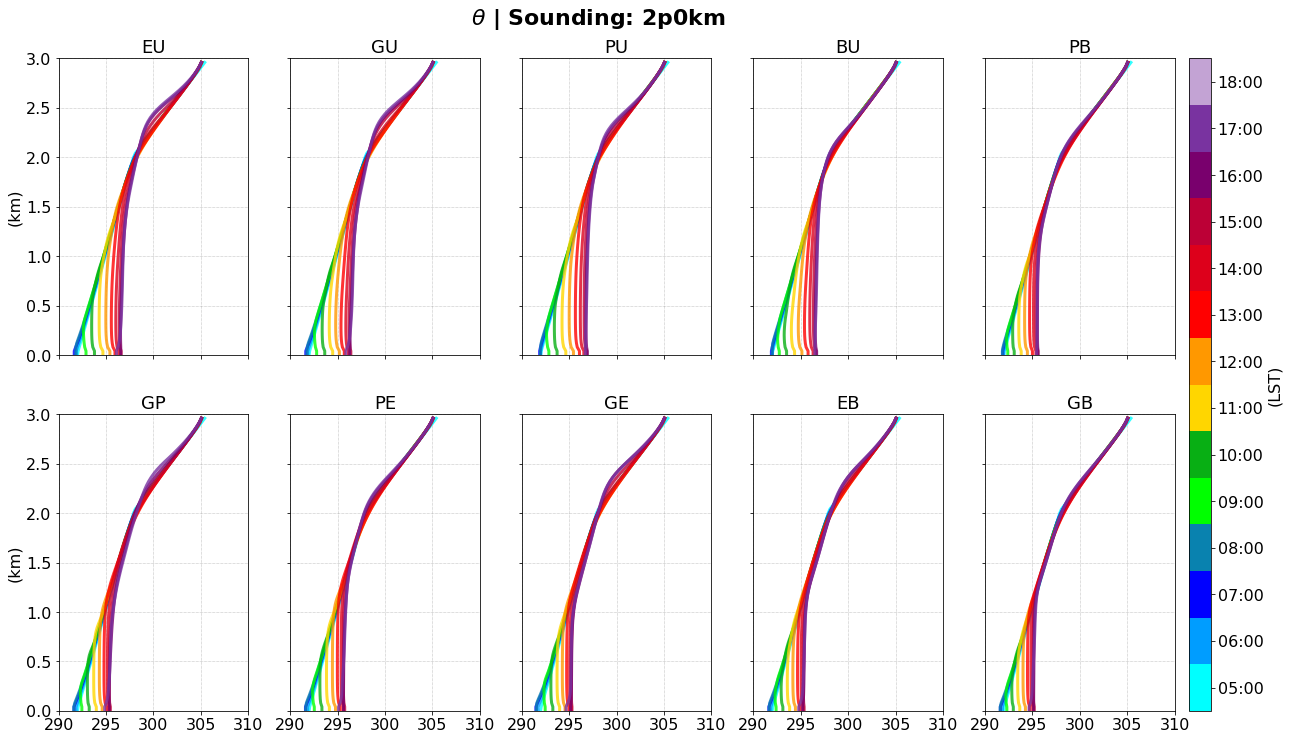

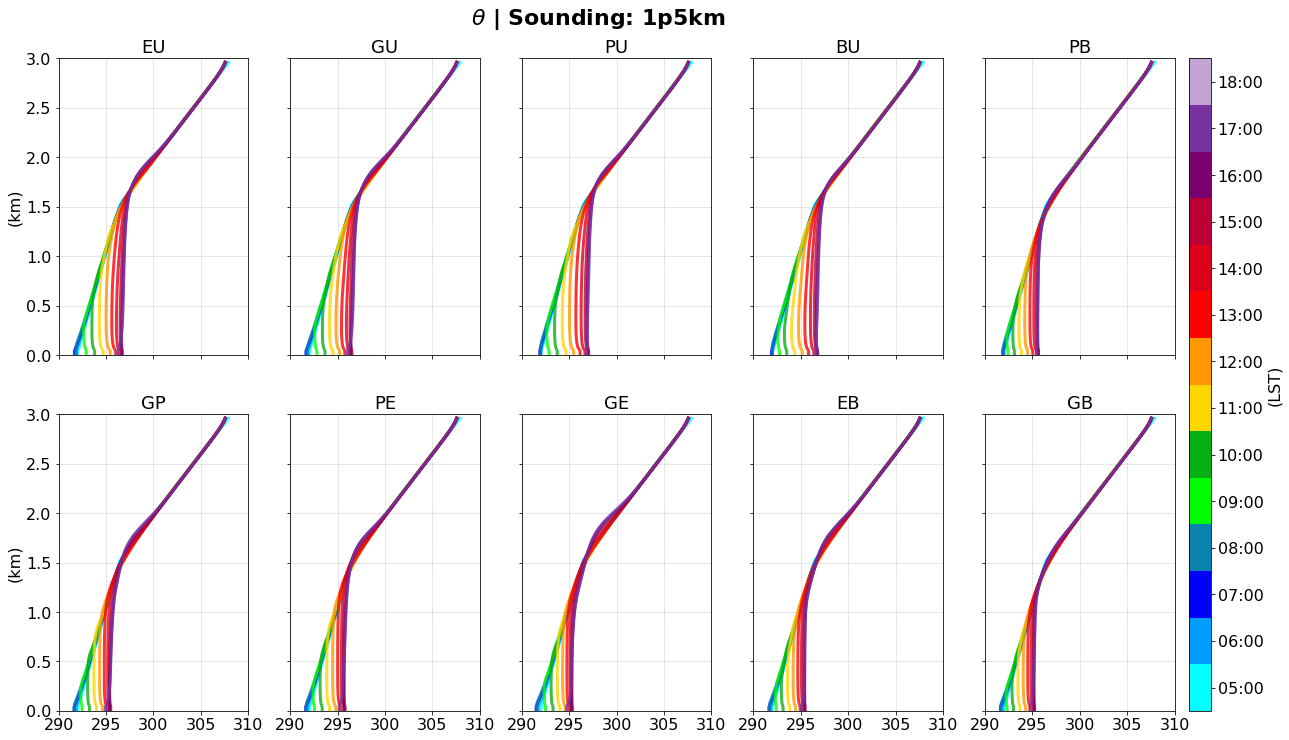

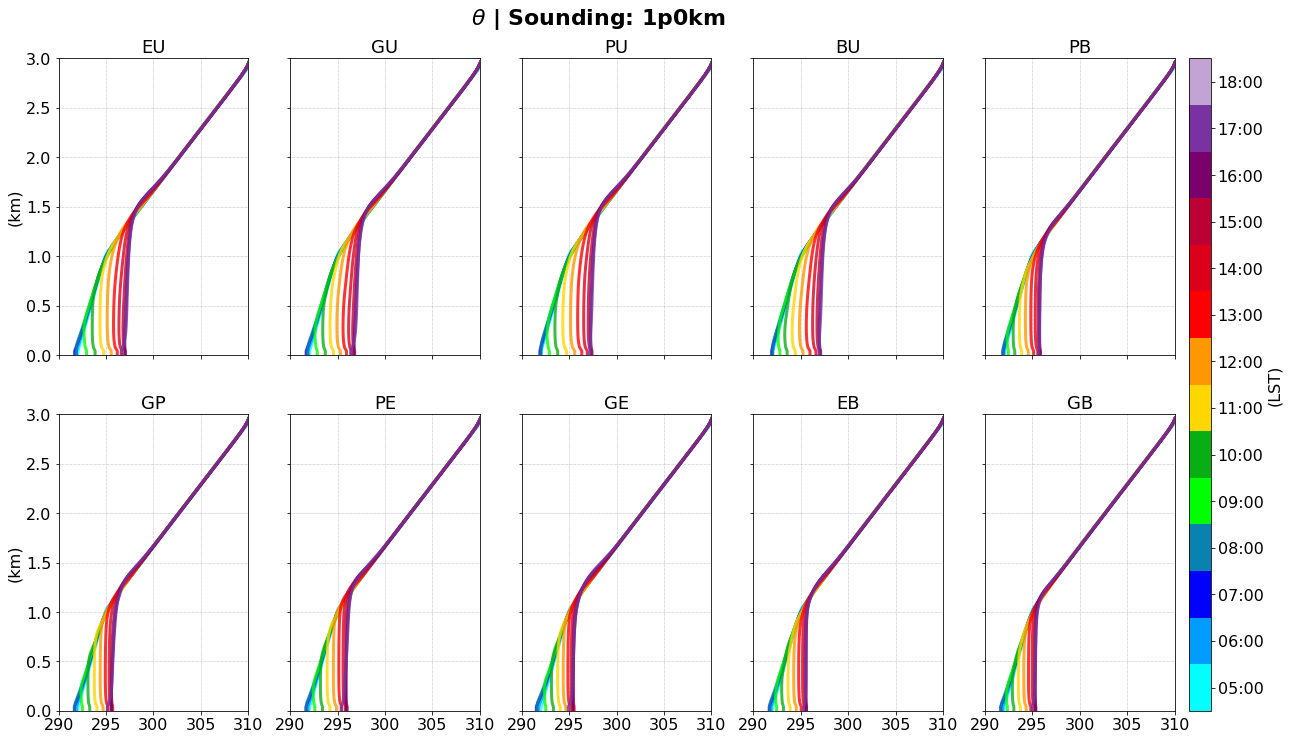

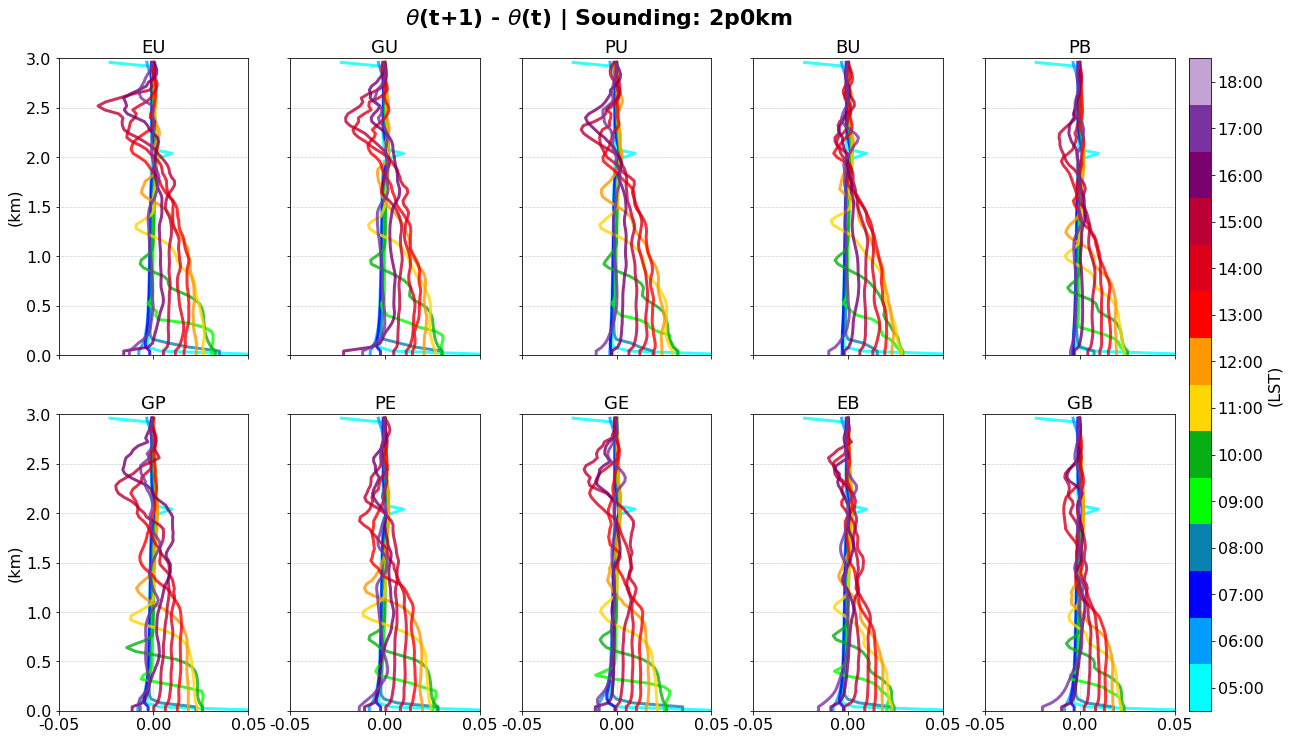

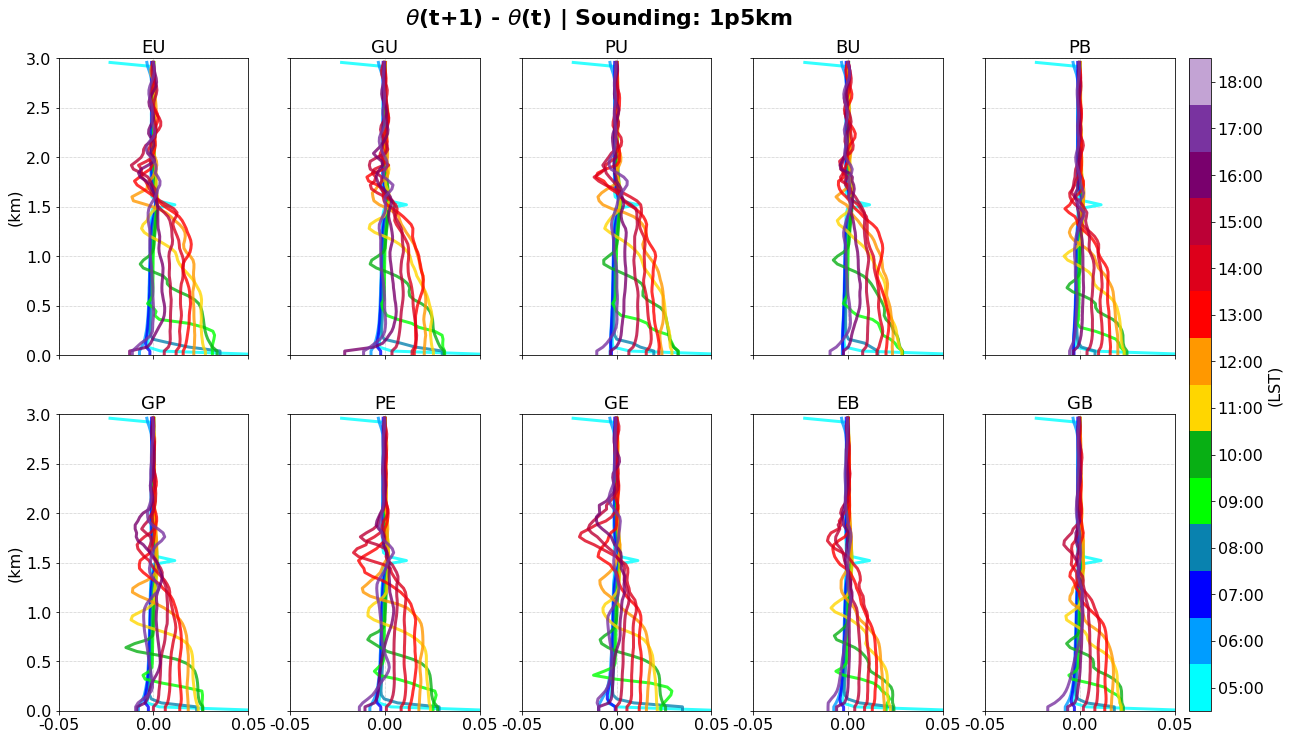

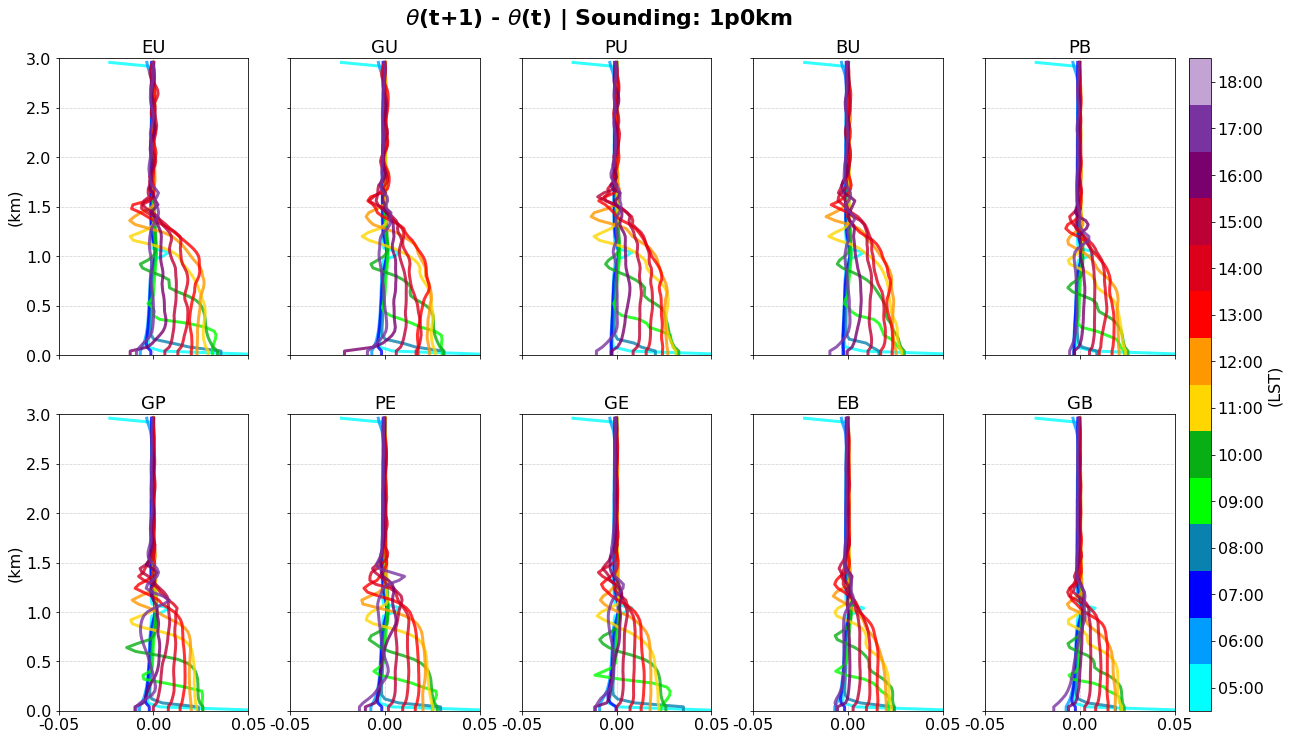

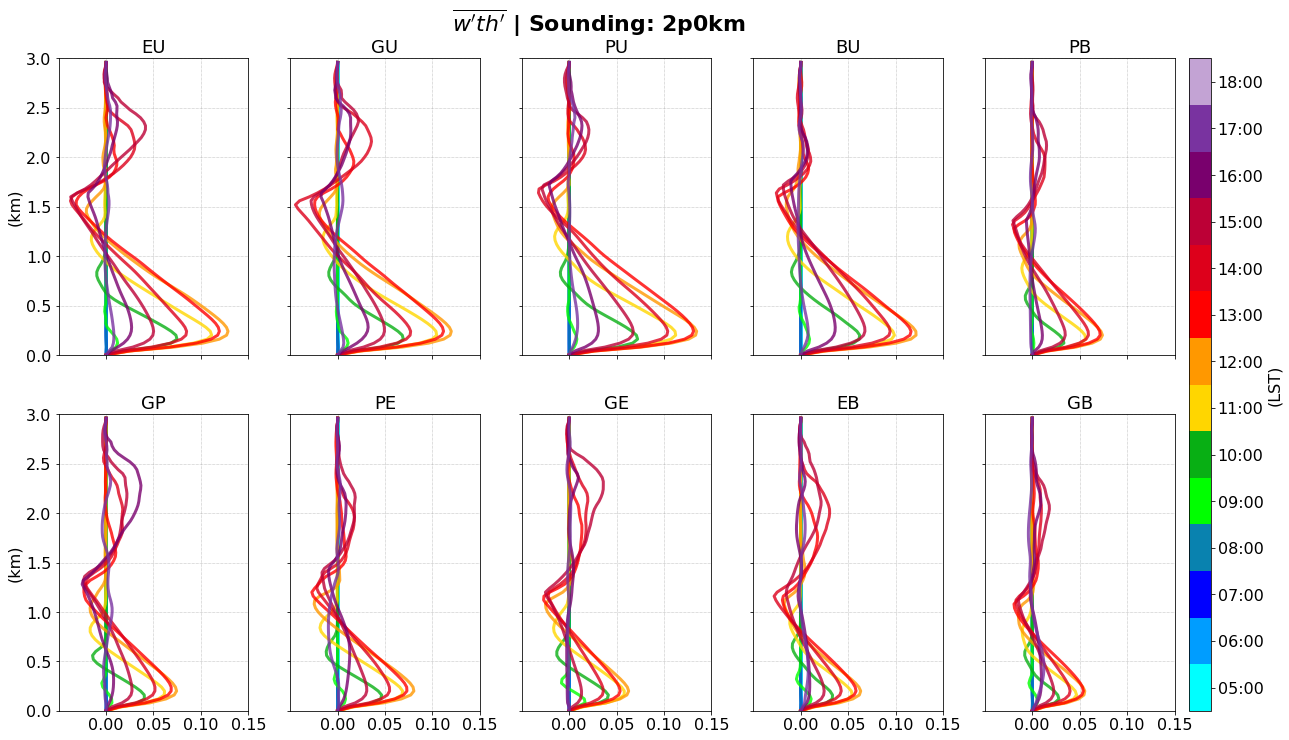

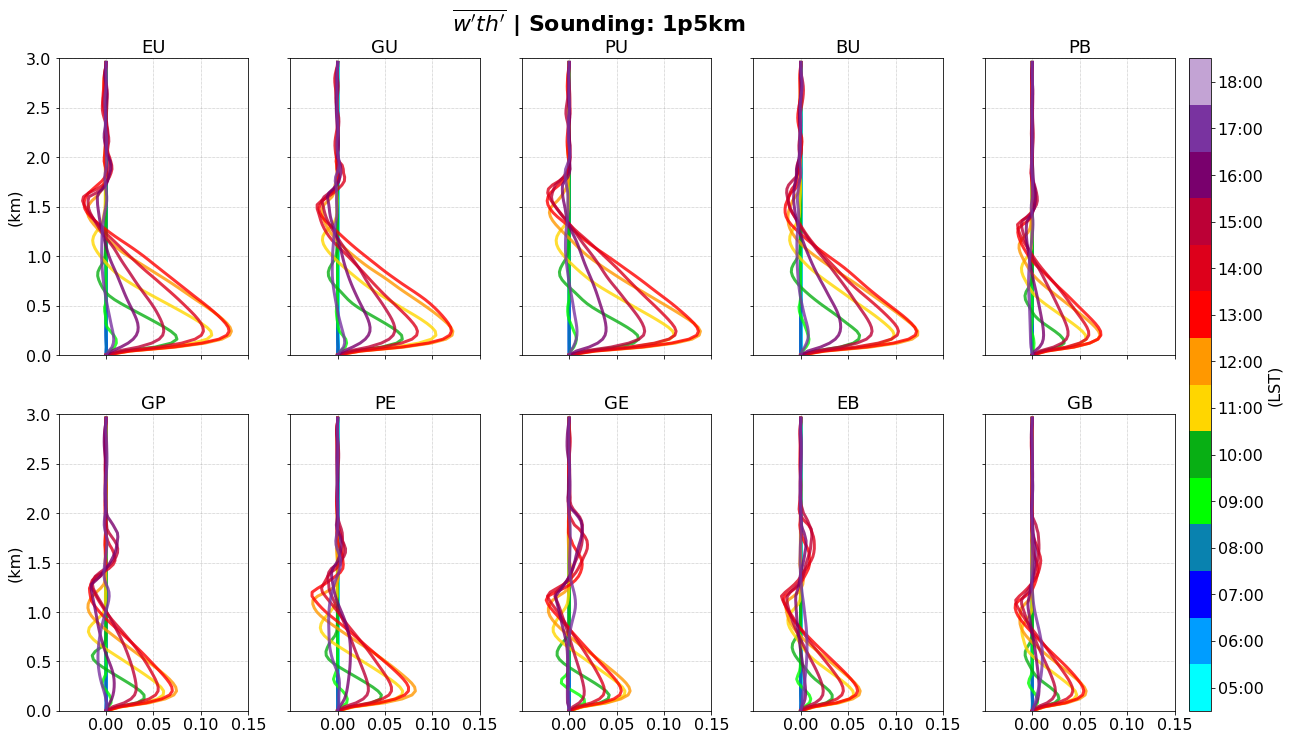

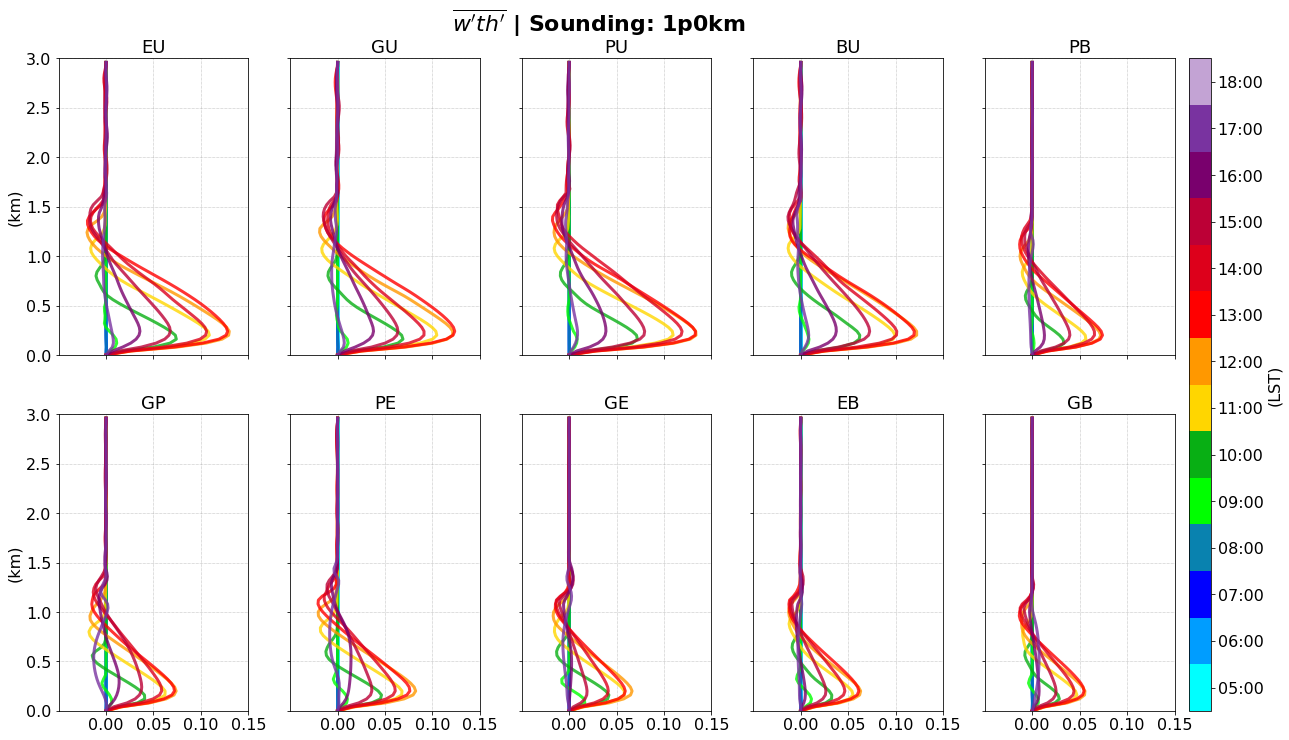

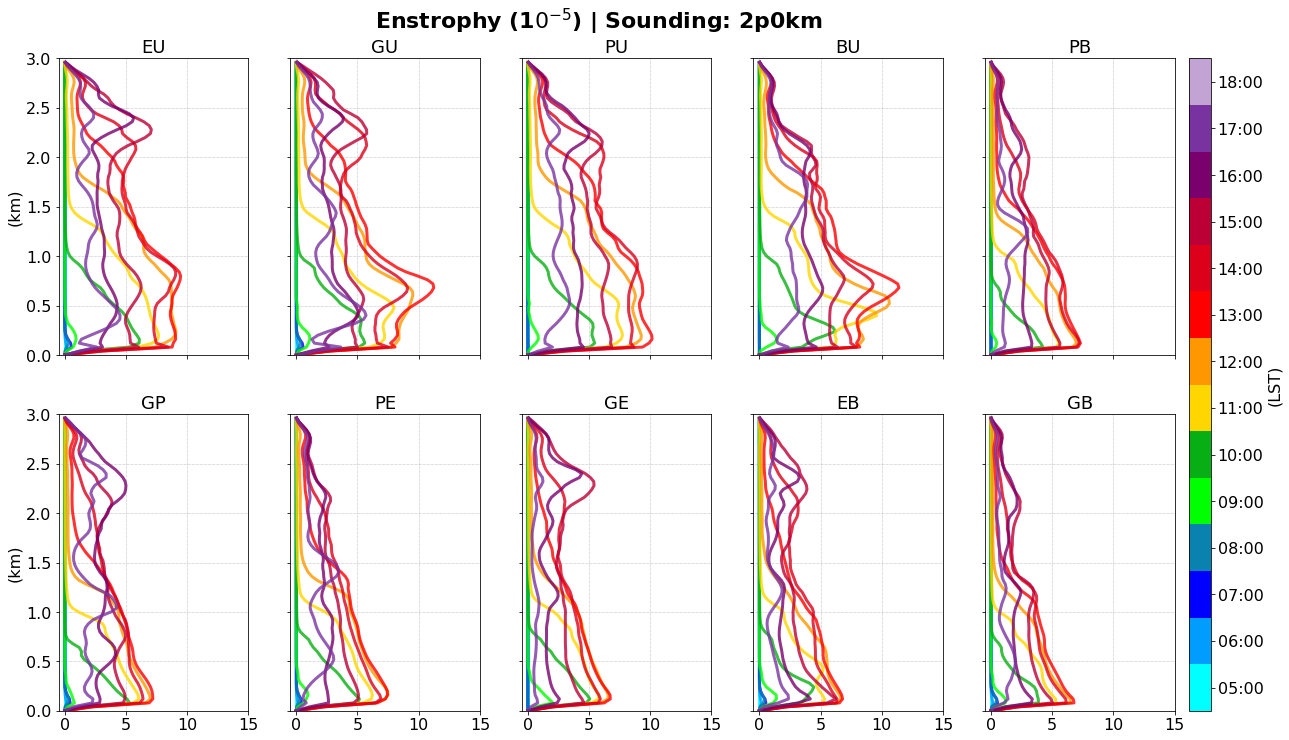

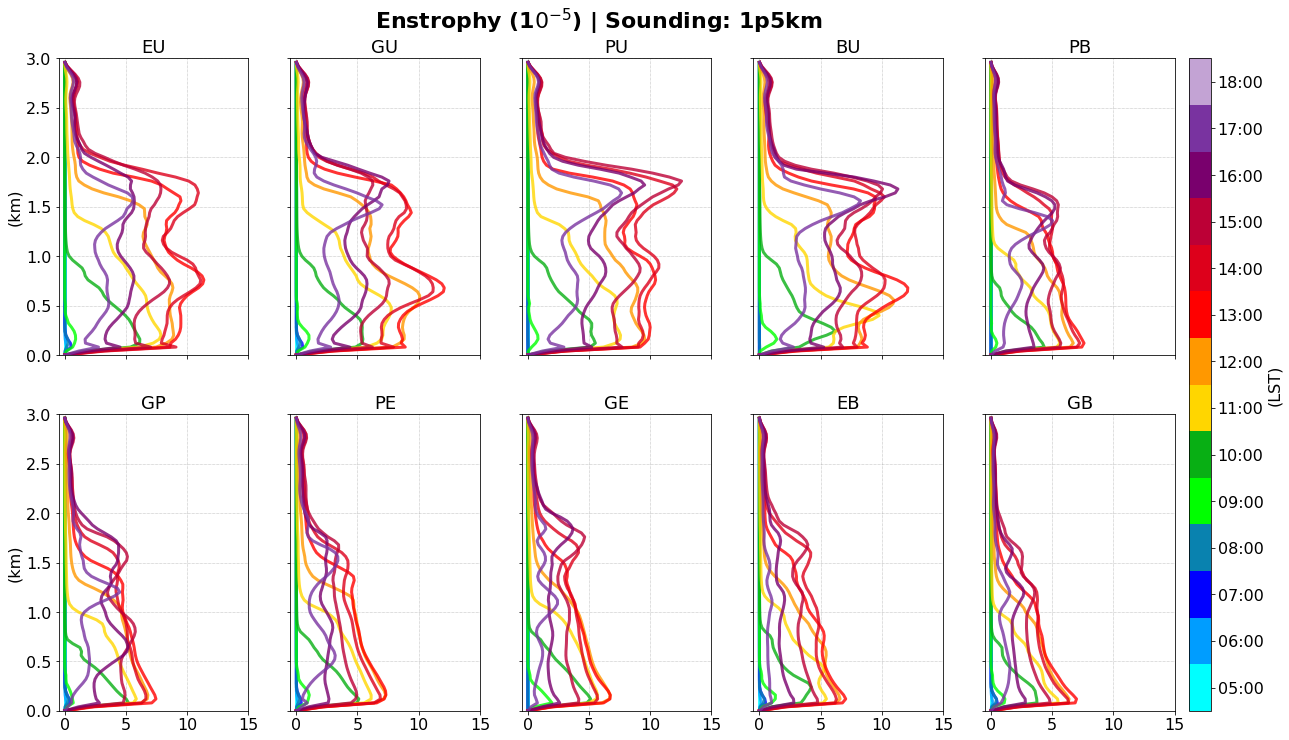

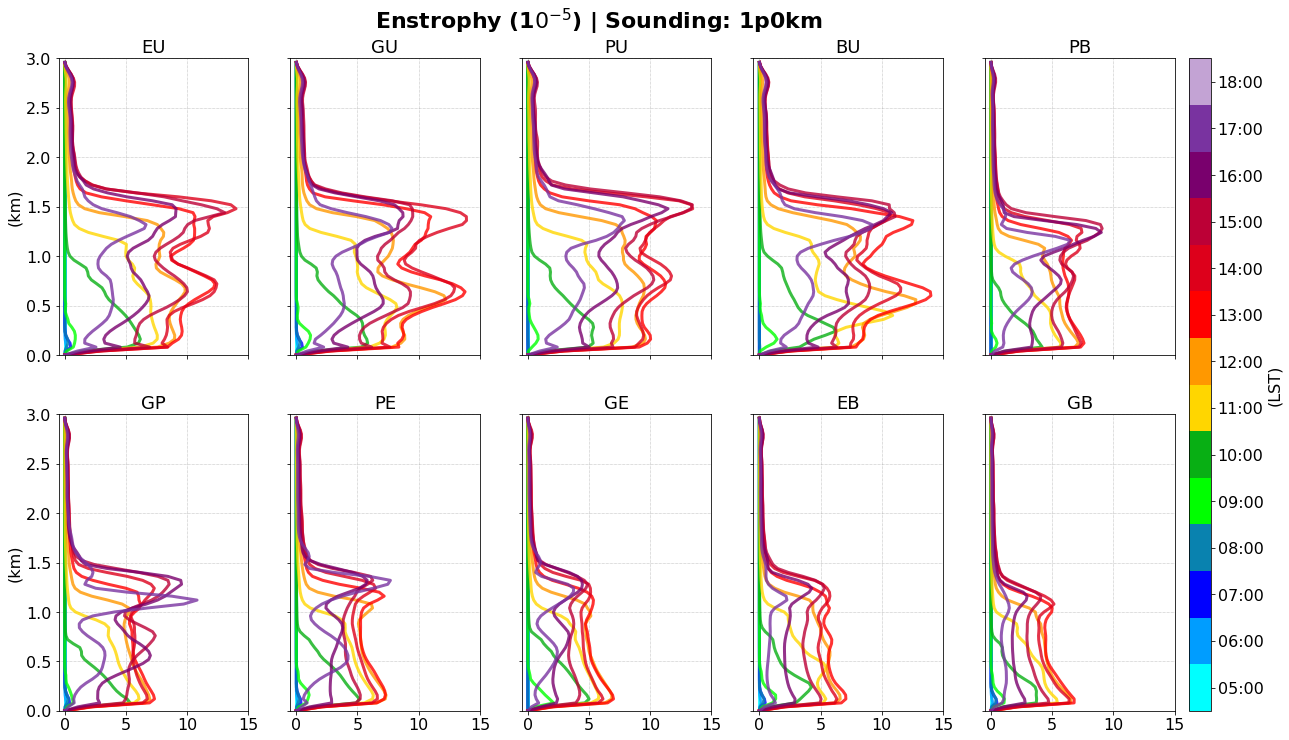

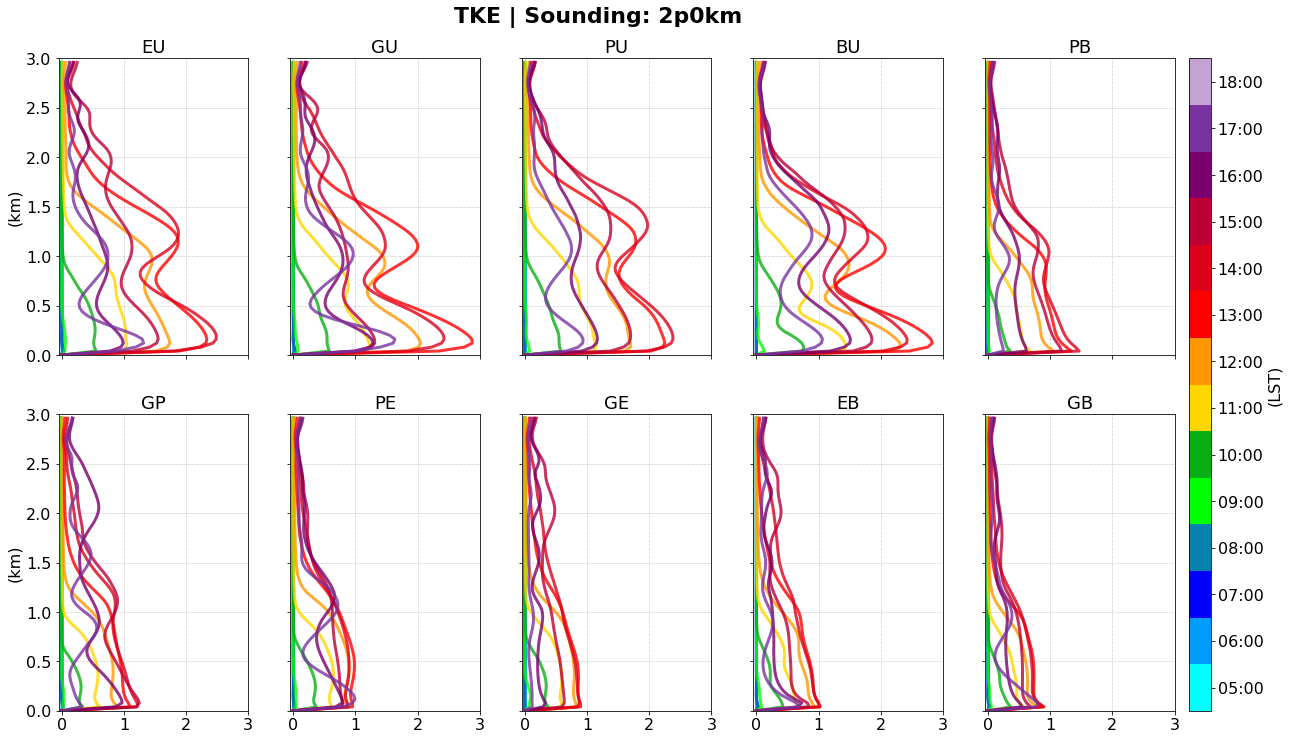

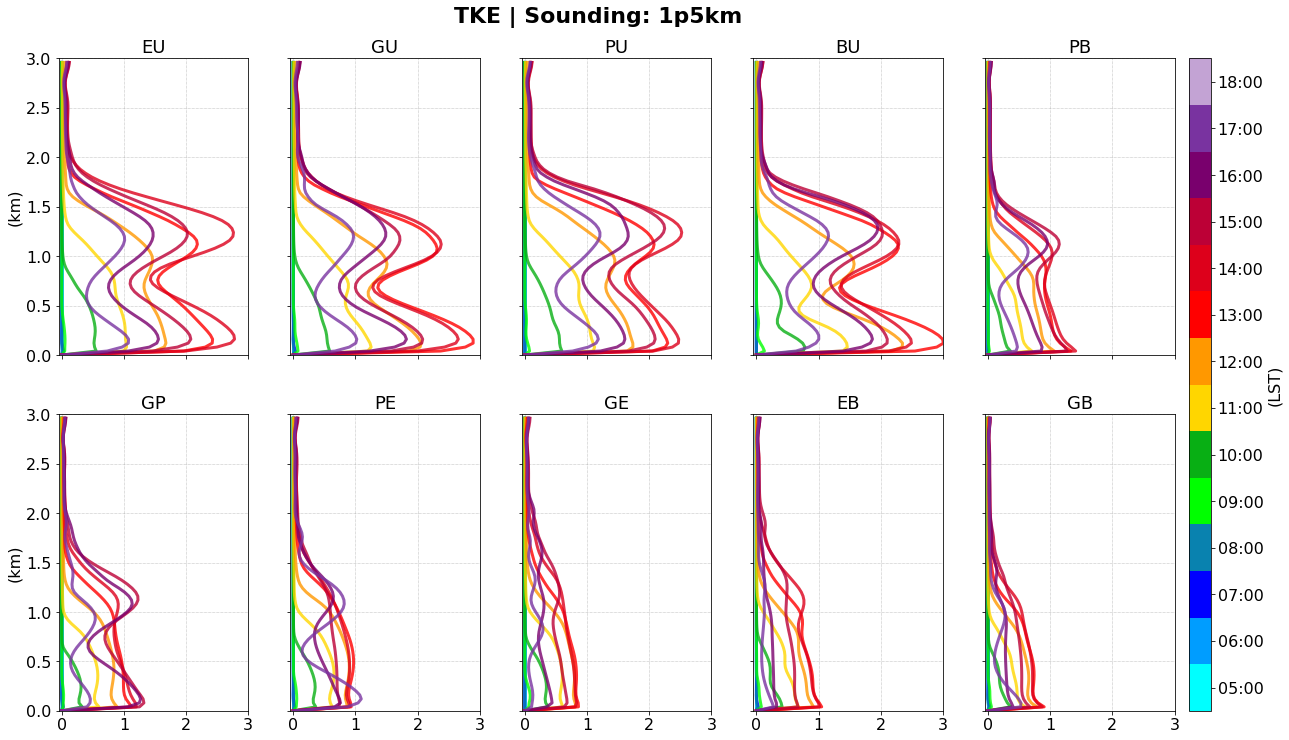

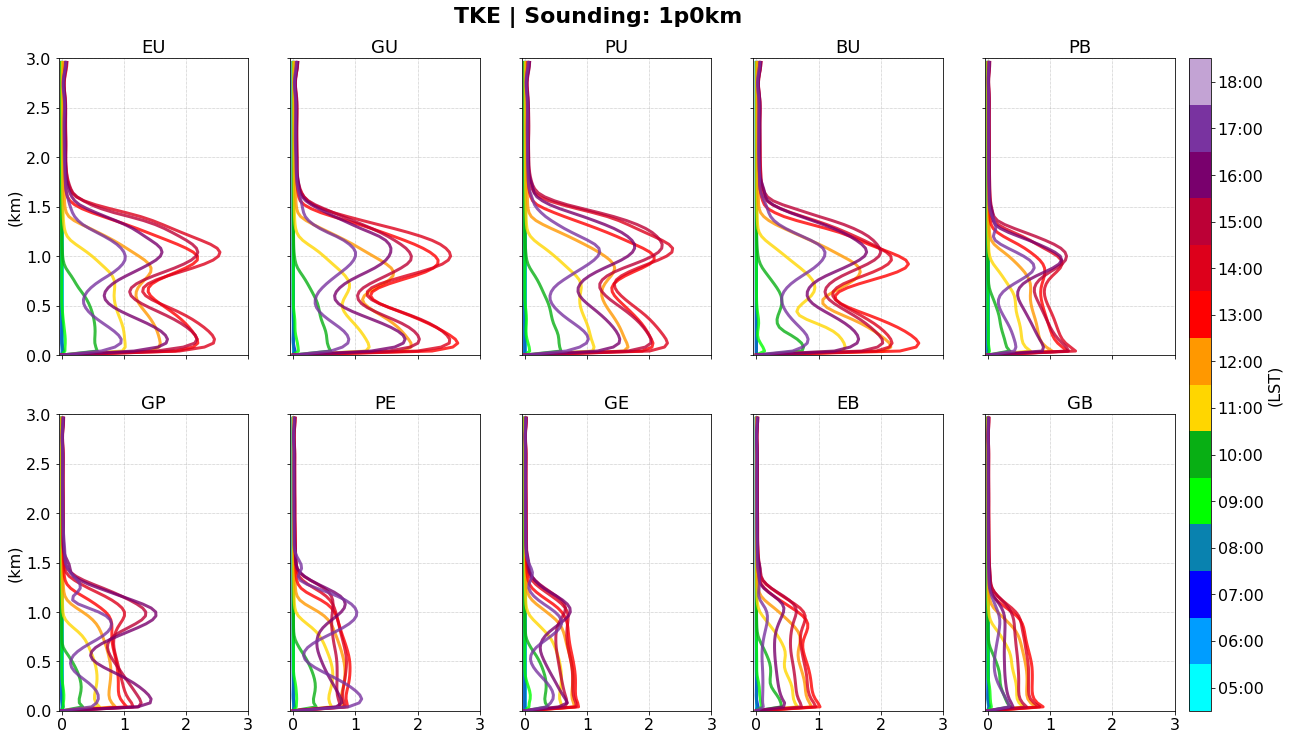

In [131]:
for var in ['th', 'th_diff', 'wth', 'enst', 'tke']:
    for sd in ['2p0km', '1p5km', '1p0km']:
        Plot_all_lu_profiles(var=var, sounding=sd, savefig=True)

## Cloud Hovmoeller

In [194]:
def Plot_all_lu_qc_hov(sounding:str, savefig:bool=False):
    # Figure initialization
    fig, ax = plt.subplots(2, 5, sharex=True, sharey=True, figsize=(23, 6), gridspec_kw={'wspace':0.16})
    # Data initialization
    lu_list = ['eu', 'gu', 'pu', 'bu', 'pb', 'gp', 'pe', 'ge', 'eb', 'gb']
    time_int= 30
    time_stp= 391
    for i, axe in enumerate(ax.flatten()):
        tools_case = vvmtoolsV2.VVMtools(f"/data/C.shaoyu/ml_pbl/pbl_{lu_list[i]}_{sounding}")
        qc_dmean   = tools_case.get_var_parallel(var='qc', time_steps=np.arange(time_stp), compute_mean=True, axis=(-2, -1))
        imqc       = axe.contourf(np.arange(time_stp), tools_case.DIM['zc'], 
                                  (np.where(qc_dmean>=1e-5, qc_dmean, np.nan)*1e3).T, 
                                  levels=np.arange(1e-2, 9.1e-2, 1e-2), cmap=cmaps.MPL_Blues, extend='both')
        ## Grid lines
        axe.grid(linestyle=':', linewidth=0.5, color='grey')
        ## Fig range
        axe.set_xticks(np.arange(0, time_stp, time_int*2))
        axe.set_xticklabels([f'{(datetime(2024, 1, 1, 5)+timedelta(seconds=time*120)).strftime("%H:%M")}' for time in range(0, time_stp, time_int*2)], fontsize=11.5)
        axe.set_ylim([0, 3000])
        axe.set_yticks(np.arange(0, 3000.1, 500))
        axe.set_yticklabels([f"{i:.1f}" for i in np.arange(0, 3.1, 0.5)], fontsize=12)
        ax[1, 2].set_xlabel('(LST)', fontsize=16)
        ax[0, 0].set_ylabel('(km)', fontsize=16)
        ax[1, 0].set_ylabel('(km)', fontsize=16)
        ## Subplot title
        axe.set_title(f"{lu_list[i].upper()}", fontsize=16)
    ## Color bar
    cax  = fig.add_axes([ax[-1, -1].get_position().x1+0.01, ax[-1, -1].get_position().y0, 
                         0.015, ax[0, -1].get_position().y1-ax[-1, -1].get_position().y0])
    cbar = fig.colorbar(imqc, cax=cax, orientation='vertical')
    cbar.set_ticks(ticks=np.arange(0.01, 0.091, 0.01), 
                   labels=[f'{_:.2f}' for _ in np.arange(0.01, 0.091, 0.01)])
    cbar.ax.tick_params(labelsize=16)
    fig.suptitle(x=0.5, y=0.99, t=f'Cloud Water (g/kg) | Sounding: {sounding}', fontsize=22, fontweight='bold')
    if savefig:
        plt.savefig(f"../Figure/all_lu_hov/qc_{sounding}.png", facecolor='w', bbox_inches='tight', dpi=400)
    else:
        plt.show()

/home/ch995334/anaconda3/envs/weiting3.7/lib/python3.9/site-packages/matplotlib/contour.py:1486: UserWarning: Warning: converting a masked element to nan.
  self.zmax = float(z.max())
/home/ch995334/anaconda3/envs/weiting3.7/lib/python3.9/site-packages/matplotlib/contour.py:1487: UserWarning: Warning: converting a masked element to nan.
  self.zmin = float(z.min())
/home/ch995334/anaconda3/envs/weiting3.7/lib/python3.9/site-packages/matplotlib/contour.py:1486: UserWarning: Warning: converting a masked element to nan.
  self.zmax = float(z.max())
/home/ch995334/anaconda3/envs/weiting3.7/lib/python3.9/site-packages/matplotlib/contour.py:1487: UserWarning: Warning: converting a masked element to nan.
  self.zmin = float(z.min())
/home/ch995334/anaconda3/envs/weiting3.7/lib/python3.9/site-packages/matplotlib/contour.py:1486: UserWarning: Warning: converting a masked element to nan.
  self.zmax = float(z.max())
/home/ch995334/anaconda3/envs/weiting3.7/lib/python3.9/site-packages/matplotlib/

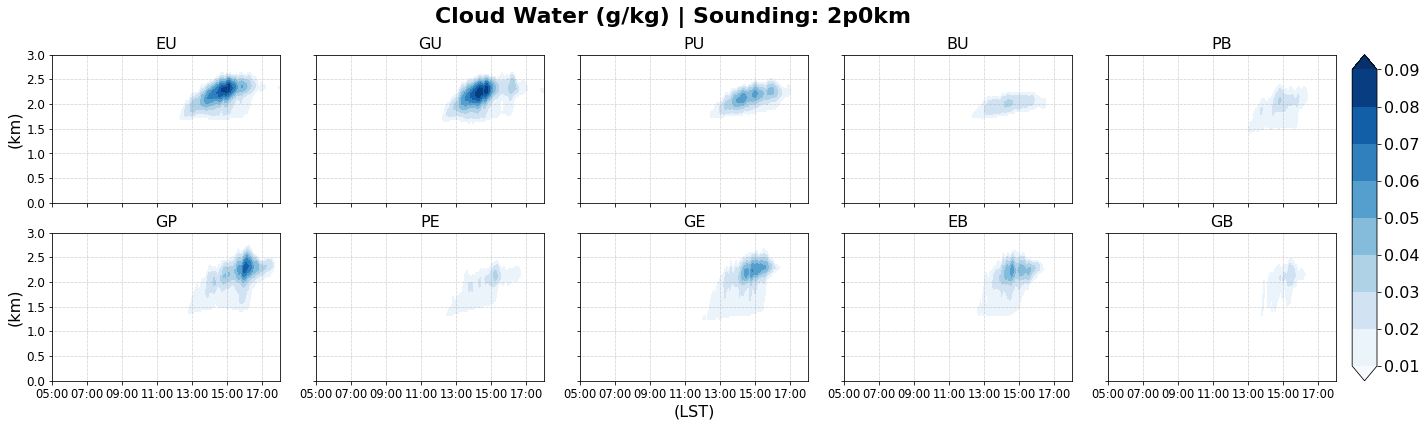

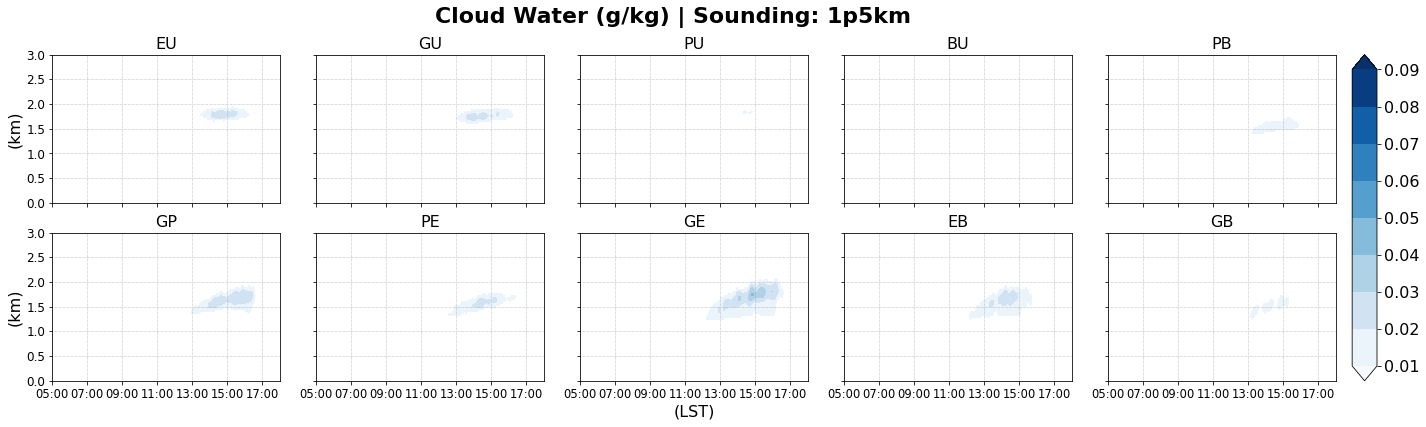

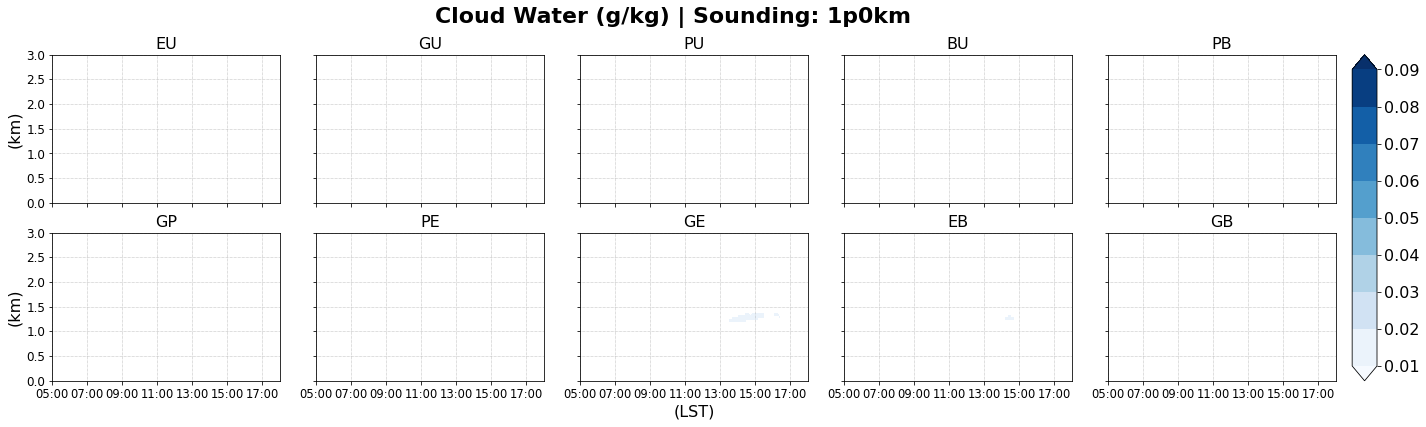

In [195]:
for sd in ['2p0km', '1p5km', '1p0km']:
    Plot_all_lu_qc_hov(sounding=sd, savefig=True)

## Test

### Vertical profiles

In [74]:
def Plot_lu_profiles(lu:str, savefig:bool=False):
    import matplotlib.cm as cm
    # Data
    ds_lus1 = xr.open_dataset(f'../TemporaryData/lu_profs/{lu}_2p0km.nc')
    # Plot
    fig, ax = plt.subplots(2, 3, sharey=True, figsize=(12, 12), gridspec_kw={'wspace':0.1})
    fig.delaxes(ax[0, 2])
    n = 25
    cmap   = cmaps.WhiteBlueGreenYellowRed[10:]
    ccolors= cmap(np.linspace(0,1,n))
    for i in range(int(721/30)):
        y = ds_lus1.height
        ax[0, 0].plot(ds_lus1.th.isel(time=int(i*30)), y, color=ccolors[i], linewidth=3)
        ax[0, 1].plot(ds_lus1.th.isel(time=int(i*30+1))-ds_lus1.th.isel(time=int(i*30)), y, color=ccolors[i], linewidth=3)
        ax[1, 0].plot(ds_lus1.wth.isel(time=int(i*30)), y, color=ccolors[i], linewidth=3)
        ax[1, 1].plot(ds_lus1.enstrophy.isel(time=int(i*30))*1e5, y, color=ccolors[i], linewidth=3)
        ax[1, 2].plot(ds_lus1.tke.isel(time=int(i*30)), y, color=ccolors[i], linewidth=3)
    ## Grid lines
    for axe in ax.flatten():
        axe.grid(linestyle=':', linewidth=0.5, color='grey')
    ## Colorbar
    bounds = np.arange(721//30)
    norm   = colors.BoundaryNorm(bounds, cmap.N)
    cax  = fig.add_axes([ax[0, 1].get_position().x1+0.01, ax[0, 1].get_position().y0, 
                         0.015, ax[0, 1].get_position().height])
    cbar = fig.colorbar(cm.ScalarMappable(cmap=cmap, norm=norm), 
                        cax=cax, orientation='vertical')
    cbar.set_ticks(ticks=((bounds[:-1]+bounds[1:])/2)[::2], 
                   labels=[f'{(datetime(2024, 1, 1, 5)+timedelta(seconds=time*120)).strftime("%H:%M")}' for time in range(0, 721-60, 30)][::2])
    cbar.ax.tick_params(labelsize=13)
    cbar.set_label('(LST)', fontsize=14)
    ## Fig range
    ax[0, 0].set_xlim([290, 310])
    ax[0, 1].set_xlim([-0.05, 0.05])
    ax[1, 0].set_xlim([-0.04, 0.15])
    ax[1, 1].set_xlim([-0.5, 15])
    ax[1, 2].set_xlim([-0.05, 3])
    ax[0, 0].set_ylim([0, 3])
    ## Fig info.
    ax[0, 0].set_title(r'$\theta$', fontsize=14)
    ax[0, 1].set_title(r'$\theta$(t+1) - $\theta$(t)', fontsize=14)
    ax[1, 0].set_title(r"$\overline{w'th'}$", fontsize=14)
    ax[1, 1].set_title(r'Enstrophy (1$0^{-5}$)', fontsize=14)
    ax[1, 2].set_title('TKE', fontsize=14)
    fig.suptitle(x=0.5, y=0.93, t=f"{lu.upper()}", fontweight='bold', fontsize=18)
    # if savefig:
    #     plt.savefig(f"./Figure/Final/lu_profs/{lu}.png", facecolor='w', bbox_inches='tight', dpi=400)
    # else:
    #     plt.show()

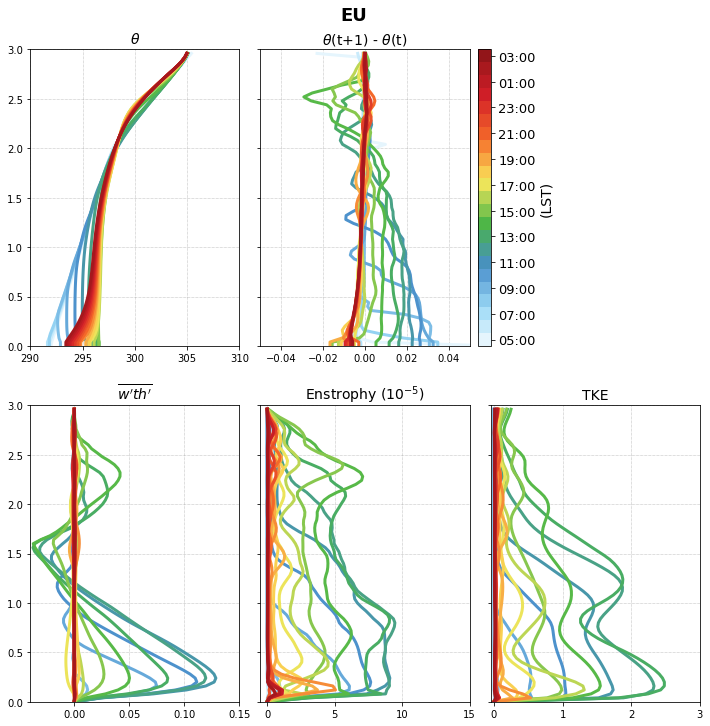

In [75]:
Plot_lu_profiles(lu='eu')

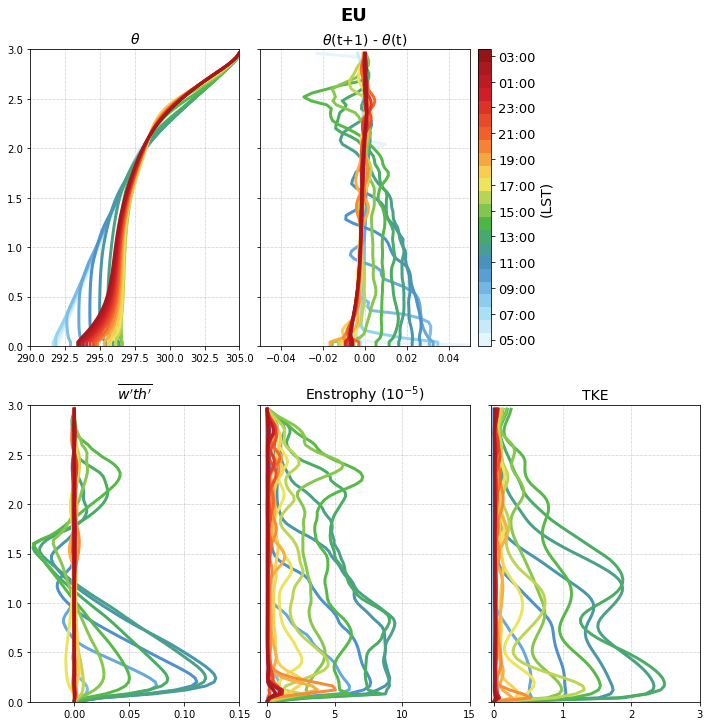

In [25]:
Plot_lu_profiles(lu='eu')

### Clouds?

In [30]:
tools_eu2p0 = vvmtoolsV2.VVMtools(f"/data/C.shaoyu/ml_pbl/pbl_eu_2p0km/")

In [31]:
qc = tools_eu2p0.get_var_parallel(var='qc', time_steps=np.arange(721))
qi = tools_eu2p0.get_var_parallel(var='qi', time_steps=np.arange(721))

In [34]:
qc_dmean, qi_dmean = qc.mean(axis=(-2, -1)), qi.mean(axis=(-2, -1))

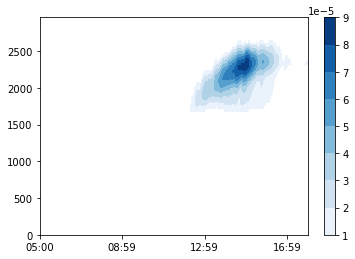

In [136]:
im_temp = plt.contourf(np.arange(tools_eu2p0.TIMESTEPS), tools_eu2p0.DIM['zc'], 
                       np.where(qc_dmean>=1e-5, qc_dmean, np.nan).T, cmap=cmaps.MPL_Blues)
plt.xticks(np.arange(tools_eu2p0.TIMESTEPS)[::120], 
           labels=tools_eu2p0.time_array_str[::120])
plt.xlim(0, 390)
plt.colorbar(im_temp)

In [39]:
len(tools_eu2p0.time_array_str)

721

In [40]:
tools_eu2p0.DIM['zc']

array([   0.,   40.,   80.,  120.,  160.,  200.,  240.,  280.,  320.,
        360.,  400.,  440.,  480.,  520.,  560.,  600.,  640.,  680.,
        720.,  760.,  800.,  840.,  880.,  920.,  960., 1000., 1040.,
       1080., 1120., 1160., 1200., 1240., 1280., 1320., 1360., 1400.,
       1440., 1480., 1520., 1560., 1600., 1640., 1680., 1720., 1760.,
       1800., 1840., 1880., 1920., 1960., 2000., 2040., 2080., 2120.,
       2160., 2200., 2240., 2280., 2320., 2360., 2400., 2440., 2480.,
       2520., 2560., 2600., 2640., 2680., 2720., 2760., 2800., 2840.,
       2880., 2920., 2960.])

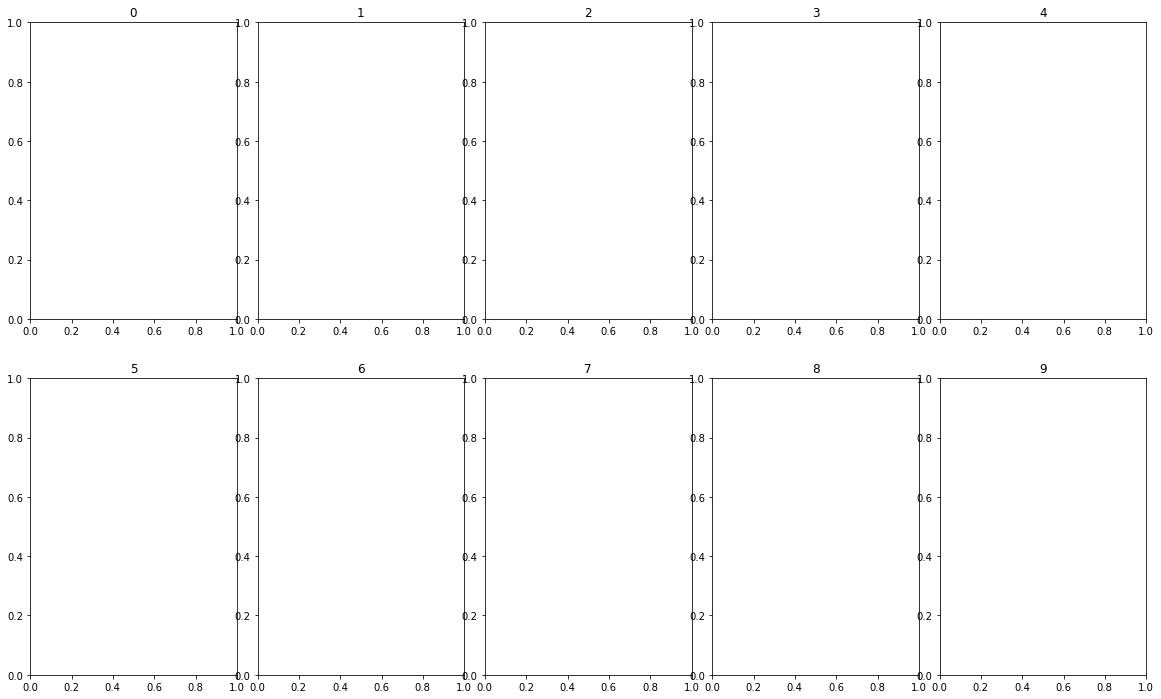

In [51]:
fig, ax = plt.subplots(2, 5, figsize=(20, 12), gridspec_kw={'wspace':0.1})
for i, axe in enumerate(ax.flatten()):
    axe.set_title(f"{i}")